In [3]:
import sys
import os
sys.path.append(os.path.abspath('/acne-lds/model'))
sys.path.append(os.path.abspath('model'))
sys.path.append(os.path.abspath("/acne-lds/utils"))

In [4]:
from model_ld_smoothing import AcneModel

/opt/anaconda3/envs/pl-env/lib/python3.9/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: dlopen(/opt/anaconda3/envs/pl-env/lib/python3.9/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libpng16.16.dylib
  Referenced from: <5F6B6919-410D-397C-98F2-12C5934F9DBE> /opt/anaconda3/envs/pl-env/lib/python3.9/site-packages/torchvision/image.so
  Reason: tried: '/Users/malfet/miniforge3/envs/py_39_torch-1.10.2/lib/libpng16.16.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/malfet/miniforge3/envs/py_39_torch-1.10.2/lib/libpng16.16.dylib' (no such file), '/Users/malfet/miniforge3/envs/py_39_torch-1.10.2/lib/libpng16.16.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/malfet/miniforge3/envs/py_39_torch-1.10.2/lib/libpng16.16.dylib' (no such file), '/Users/malfet/miniforge3/envs/py_39_torch-1.10.2/lib/libpng16.16.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/malfet/miniforg

In [5]:
from predict_on_img import ModelInit
from PIL import Image

model = ModelInit(path_checkpoint='model/lds-weights/model_fold_4.pth')
# img = Image.open(PATH_TO_IMAGE)
# predictions = model.predict_on_img(img)

In [56]:
# Assume ModelInit is imported and your checkpoint path is correct
import torch
model_wrapper = ModelInit(model_type="model_ld_smoothing", path_checkpoint="model/lds-weights/model_fold_4.pth", device="cpu")
model = model_wrapper.model
model.eval()

# Dummy input tensor (use actual input size expected, e.g. 3x224x224)
example_input = torch.randn(1, 3, 224, 224)
traced_model = torch.jit.trace(model, example_input)

In [57]:
import torch
from torch import nn
from collections import namedtuple

from torchvision import transforms
# Define a namedtuple for outputs
ModelOutput = namedtuple("ModelOutput", ["cls_pred", "lesion_count"])

class ModelWrapper(nn.Module):
    def __init__(self, model, model_type="model_ld_smoothing"):
        super().__init__()
        self.model = model
        self.model_type = model_type

    def forward(self, x):
        cls, cou, cou2cls = self.model(x)

        if self.model_type == "model_ld_smoothing":
            cls = torch.stack(
                (
                    torch.sum(cls[:, :1], 1),
                    torch.sum(cls[:, 1:4], 1),
                    torch.sum(cls[:, 4:10], 1),
                    torch.sum(cls[:, 10:], 1),
                ),
                dim=1,
            )

        cls_pred = torch.argmax(0.5 * (cls + cou2cls), dim=1)
        lesion_count = torch.argmax(cou, dim=1) + 1

        return ModelOutput(cls_pred, lesion_count)

# Wrap your model
# Initialize model (make sure the path is correct)
model_wrapper = ModelInit(model_type="model_ld_smoothing", path_checkpoint="model/lds-weights/model_fold_4.pth", device="cpu")
model_2 = model_wrapper.model
model_2.eval()

wrapped_model = ModelWrapper(model_2)
wrapped_model.eval()
# Then trace the wrapped model

traced_model = torch.jit.trace(wrapped_model, example_input)

In [58]:
image_input = ct.ImageType(
    name="input_image",
    shape=(1, 3, 224, 224),                 
    scale=1.0/255.0/0.226,   # list of 3 scales (1/std per channel)
    bias=[-0.45815152/0.2814769, 
          -0.361242  /0.226306, 
          -0.29348266/0.20132513],                  
    color_layout=ct.colorlayout.RGB,)

coreml_model = ct.convert(
    traced_model,
    convert_to="neuralnetwork",
    inputs=[ image_input ],
)
# coreml_model.save("AcneClassification.mlmodel")

Tuple detected at graph output. This will be flattened in the converted model.
Running MIL default pipeline:   0%|          | 0/69 [00:00<?, ? passes/s]/opt/anaconda3/envs/pl-env/lib/python3.9/site-packages/coremltools/converters/mil/mil/passes/defs/preprocess.py:267: UserWarning: Output, '910', of the source model, has been renamed to 'var_910' in the Core ML model.
  warnings.warn(msg.format(var.name, new_name))
/opt/anaconda3/envs/pl-env/lib/python3.9/site-packages/coremltools/converters/mil/mil/passes/defs/preprocess.py:267: UserWarning: Output, '916', of the source model, has been renamed to 'var_916' in the Core ML model.
  warnings.warn(msg.format(var.name, new_name))
Running MIL backend_neuralnetwork pipeline:   0%|          | 0/9 [00:00<?, ? passes/s]Output var var_910 of type int32 in function main is cast to type fp32
Output var var_916 of type int32 in function main is cast to type fp32
Translating MIL ==> NeuralNetwork Ops: 100%|██████████| 527/527 [00:17<00:00, 30.09 ops/

In [59]:
coreml_model_lut = ct.models.neural_network.quantization_utils.quantize_weights(
    coreml_model,
    nbits=8, 
    quantization_mode="linear_lut"
)

Quantizing using linear_lut quantization
Optimizing Neural Network before Quantization:
Finished optimizing network. Quantizing neural network..
Quantizing layer input.3 of type convolution
Quantizing layer input.11 of type convolution
Quantizing layer input.17 of type convolution
Quantizing layer out.1 of type convolution
Quantizing layer residual.1 of type convolution
Quantizing layer input.31 of type convolution
Quantizing layer input.37 of type convolution
Quantizing layer out.3 of type convolution
Quantizing layer input.49 of type convolution
Quantizing layer input.55 of type convolution
Quantizing layer out.5 of type convolution
Quantizing layer input.67 of type convolution
Quantizing layer input.73 of type convolution
Quantizing layer out.7 of type convolution
Quantizing layer residual.3 of type convolution
Quantizing layer input.87 of type convolution
Quantizing layer input.93 of type convolution
Quantizing layer out.9 of type convolution
Quantizing layer input.105 of type conv

In [60]:
coreml_model_lut.save("AcneClassQuantFin.mlpackage")

In [64]:
img = Image.open('../data/acne04-1/train/images/levle1_143_jpg.rf.509bf1d45ba1d1f6848d1f076bc44863.jpg')

In [65]:
from PIL import Image
import numpy as np
img_resized = img.resize((224, 224))

In [66]:
outputs = coreml_model.predict({"input_image": img_resized})

In [67]:
outputs.values()

dict_values([array([9.], dtype=float32), array([1.], dtype=float32)])

In [68]:
coreml_model_lut.predict({"input_image": img_resized})

{'var_916': array([9.], dtype=float32), 'var_910': array([1.], dtype=float32)}

In [71]:
cls, cou, cou2cls = model.predict_on_img(img)

## model comparisons

In [78]:
!pip install ultralytics

  Using cached ultralytics-8.3.124-py3-none-any.whl.metadata (37 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-macosx_13_0_arm64.whl.metadata (20 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.4 MB/s eta 0:00:00
  Using cached py_cpuinfo-9.0.0-py3-none-any.whl.metadata (794 bytes)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 1.7 MB/s eta 0:00:00a 0:00:01
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached ultralytics_thop-2.0.14-py3-none-any.whl.metadata (9.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 2.4 MB/s eta 0:00:00a 0:00:01
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached ultralytics-8.3.124-py3

In [2]:
from ultralytics import YOLO
yolo_model = YOLO("../notebooks/runs/detect/yolov11m_acne04/weights/best.pt")

/opt/anaconda3/envs/pl-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
import coremltools as ct
quantised_model = ct.models.MLModel("../app/SkinSnap/SkinSnap/AcneClassQuantFin.mlpackage")
## grouth truth
gt_model = ModelInit(path_checkpoint='model/lds-weights/model_fold_4.pth')

In [96]:
# size, inference speed and accuracy
        # Initialize accumulators for errors
yolo_class_error_total = 0
yolo_lesion_error_total = 0
quantised_class_error_total = 0
quantised_lesion_error_total = 0
true_lesion_vals = 0
for images in ["test", "valid"]:
    for image in os.listdir(f"../data/acne04-1/{images}/images"):
        img = Image.open(f"../data/acne04-1/{images}/images/{image}")
        # Resize the image for YOLO model
        img_resized_yolo = img.resize((1504, 1504))
        yolo_results = yolo_model.predict(img_resized_yolo, verbose=False, conf=0.25)

        # Resize the image for CoreML models
        img_resized = img.resize((224, 224))
        quantised_outputs = quantised_model.predict({"input_image": img_resized})
        gt_cls, gt_cou, gt_cou2cls = gt_model.predict_on_img(img)

        # Print the results
        # Calculate ground truth number of lesions
        gt_num_lesions = torch.argmax(gt_cou, dim=1).item() + 1

        # Calculate YOLO number of lesions (number of bounding boxes)
        yolo_num_lesions = len(yolo_results[0].boxes)

        # Calculate quantised model number of lesions
        quantised_num_lesions = quantised_outputs["var_916"].item()

        # Store class predictions
        yolo_class_pred = yolo_results[0].boxes.cls[0].item() if len(yolo_results[0].boxes) > 0 else None
        quantised_class_pred = quantised_outputs["var_910"].item()
        gt_class_pred = torch.argmax(gt_cls, dim=1).item()

        # Calculate misclassification and accuracy error
        class_misclassification_error = int(yolo_class_pred != gt_class_pred) + int(quantised_class_pred != gt_class_pred)
        lesion_accuracy_error = abs(yolo_num_lesions - gt_num_lesions) + abs(quantised_num_lesions - gt_num_lesions)



        # YOLO vs Ground Truth
        yolo_class_error = int(yolo_class_pred != gt_class_pred)
        yolo_lesion_error = abs(yolo_num_lesions - gt_num_lesions)
        yolo_class_error_total += yolo_class_error
        yolo_lesion_error_total += yolo_lesion_error

        # Quantised Model vs Ground Truth
        quantised_class_error = int(quantised_class_pred != gt_class_pred)
        quantised_lesion_error = abs(quantised_num_lesions - gt_num_lesions)
        quantised_class_error_total += quantised_class_error
        quantised_lesion_error_total += quantised_lesion_error
        true_lesion_vals += gt_num_lesions

        # Print aggregated results
print("YOLO Total Class Error:", yolo_class_error_total)
print("YOLO Total Lesion Error:", yolo_lesion_error_total  /true_lesion_vals)
print("Quantised Model Total Class Error:", quantised_class_error_total)
print("Quantised Model Total Lesion Error:", quantised_lesion_error_total / true_lesion_vals)



        
        # img_resized = img.resize((224, 224))
        # outputs = quantised_model.predict({"input_image": img_resized})
        # cls, cou, cou2cls = gt_model.predict_on_img(img)
        # print(outputs.values())
        # print(cls, cou, cou2cls)

YOLO Total Class Error: 227
YOLO Total Lesion Error: 0.9788439743105403
Quantised Model Total Class Error: 17
Quantised Model Total Lesion Error: 0.1106913486966377


In [98]:
total = 0
for images in ["test", "valid"]:
    for image in os.listdir(f"../data/acne04-1/{images}/images"):
        total += 1

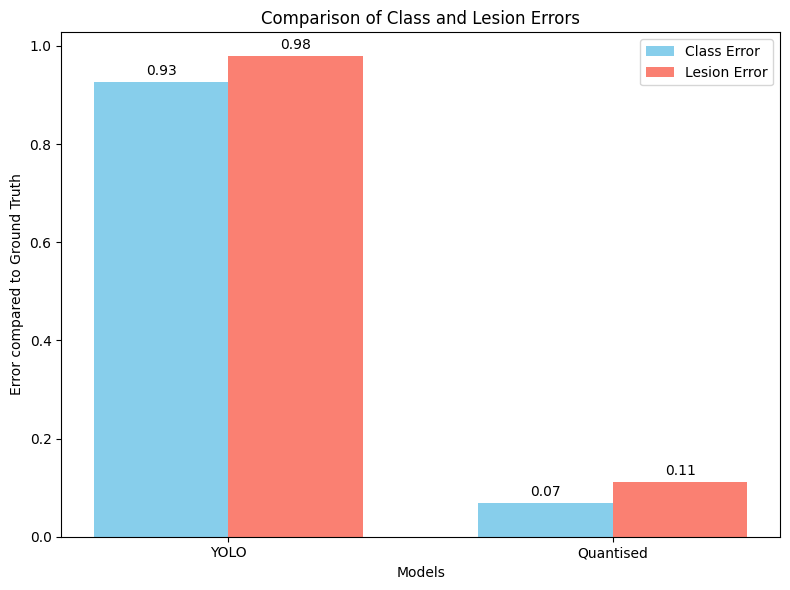

In [100]:
import numpy as np

import matplotlib.pyplot as plt

# Data for the plot
models = ['YOLO', 'Quantised']
class_errors = [yolo_class_error_total / total, quantised_class_error_total / total]
lesion_errors = [yolo_lesion_error_total / true_lesion_vals, quantised_lesion_error_total / true_lesion_vals]

# Create a bar plot
x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
bar1 = ax.bar(x - width/2, class_errors, width, label='Class Error', color='skyblue')
bar2 = ax.bar(x + width/2, lesion_errors, width, label='Lesion Error', color='salmon')

# Add labels, title, and legend
ax.set_xlabel('Models')
ax.set_ylabel('Error compared to Ground Truth')
ax.set_title('Comparison of Class and Lesion Errors')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Annotate bars with their values
for bar in bar1 + bar2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [11]:
import time

# Measure inference speed for YOLO model
yolo_times = []
img = Image.open(f"../data/acne04-1/train/images/levle0_1_jpg.rf.c634036622539e555f8532873a1c4c72.jpg")
img_resized_yolo = img.resize((1504, 1504))
yolo_results = yolo_model.predict(img_resized_yolo, verbose=False, conf=0.25)

# Resize the image for CoreML models
img_resized = img.resize((224, 224))
quantised_outputs = quantised_model.predict({"input_image": img_resized})
gt_cls, gt_cou, gt_cou2cls = gt_model.predict_on_img(img)

for _ in range(10):
    start_time = time.time()
    yolo_results = yolo_model.predict(img_resized_yolo, verbose=False, conf=0.25)
    yolo_times.append(time.time() - start_time)
avg_yolo_time = sum(yolo_times) / len(yolo_times)

# Measure inference speed for Quantised CoreML model
quantised_times = []
for _ in range(10):
    start_time = time.time()
    quantised_outputs = quantised_model.predict({"input_image": img_resized})
    quantised_times.append(time.time() - start_time)
avg_quantised_time = sum(quantised_times) / len(quantised_times)


# Measure inference speed for Quantised CoreML model
full_times = []
for _ in range(10):
    start_time = time.time()
    quantised_outputs = gt_model.predict_on_img(img_resized)
    full_times.append(time.time() - start_time)
avg_quantised_time = sum(full_times) / len(full_times)

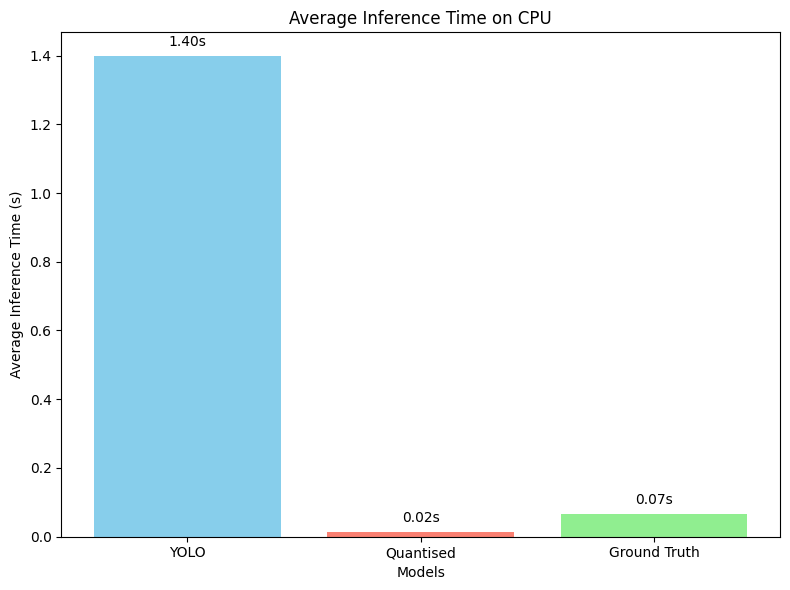

In [13]:
import matplotlib.pyplot as plt

# Data for the plot
models = ['YOLO', 'Quantised', 'Ground Truth']
avg_times = [avg_yolo_time, avg_quantised_time, avg_full_times]

# Create a bar plot
plt.figure(figsize=(8, 6))
plt.bar(models, avg_times, color=['skyblue', 'salmon', 'lightgreen'])

# Add labels, title, and values on top of bars
plt.xlabel('Models')
plt.ylabel('Average Inference Time (s)')
plt.title('Average Inference Time on CPU')
for i, time in enumerate(avg_times):
    plt.text(i, time + 0.02, f'{time:.2f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()